# Manufactoria pass-rate plots

Pulls per-test-index `eval/manufactoria_test_pass_rate_by_index_table` tables from W&B project `ai2-llm/open_instruct_internal`, intersects to a shared `test_index` population, buckets prompts by difficulty (`easy` / `medium` / `hard`) according to either the initial model or the adapted (training-step ~100) model, and plots mean pass-rate over training steps. Uses the same seaborn paper theme as `gsm8k.ipynb`.

In [1]:
from __future__ import annotations

import json
import os
from concurrent.futures import ThreadPoolExecutor
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import wandb
from matplotlib.lines import Line2D

try:
    import seaborn as sns
except ImportError as exc:
    raise ImportError("This notebook requires seaborn. Install it in the active environment before running.") from exc

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)

In [2]:
PROJECT_PATH = "ai2-llm/open_instruct_internal"
TABLE_KEY = "eval/manufactoria_test_pass_rate_by_index_table"

RUNS = {
    "init":    f"{PROJECT_PATH}/ubai8ec4",
    "base_lo": f"{PROJECT_PATH}/e7k1e8sd",
    "base_hi": f"{PROJECT_PATH}/ym0d6bhz",
}

ADAPTED_TARGET_STEP = 100
STEP_BIN = 500

CACHE_ROOT = Path("/tmp/manufac_analysis")
CACHE_ROOT.mkdir(parents=True, exist_ok=True)

REPO_OR_NOTEBOOK_DIR = Path.cwd()
OUTPUT_DIR = (REPO_OR_NOTEBOOK_DIR if REPO_OR_NOTEBOOK_DIR.name == "notebooks" else REPO_OR_NOTEBOOK_DIR / "notebooks") / "figures"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

BUCKET_ORDER = ["easy", "medium", "hard"]
BUCKET_COLORS = {"easy": "#2ca25f", "medium": "#f28e2b", "hard": "#d62728"}

api = wandb.Api(timeout=90)

wandb: [wandb.Api()] Loaded credentials for https://api.wandb.ai from /home/mnoukhov/.netrc.


## Pull W&B per-index tables

In [3]:
def list_table_refs(run_path: str) -> tuple[wandb.apis.public.Run, list[tuple[int, str]]]:
    run = api.run(run_path)
    rows: list[tuple[int, str]] = []
    for row in run.scan_history(keys=["_step", TABLE_KEY]):
        ref = row.get(TABLE_KEY)
        if ref:
            rows.append((int(row["_step"]), ref["path"]))
    return run, sorted(rows)


def download_table(run: wandb.apis.public.Run, label: str, step: int, file_path: str) -> str:
    out_dir = CACHE_ROOT / label / f"step_{step}"
    out_dir.mkdir(parents=True, exist_ok=True)
    local = out_dir / file_path
    if local.exists() and local.stat().st_size > 0:
        return str(local)
    f = run.file(file_path).download(root=str(out_dir), exist_ok=True, replace=True)
    return f.name


def load_pass_rate_table(local_path: str) -> dict[int, float]:
    with open(local_path) as fp:
        d = json.load(fp)
    ti = d["columns"].index("test_index")
    pr = d["columns"].index("pass_rate")
    return {int(row[ti]): float(row[pr]) for row in d["data"]}


def collect_run_tables(runs: dict[str, str]) -> dict[str, dict[int, dict[int, float]]]:
    """Returns {label: {step: {test_index: pass_rate}}}."""
    out: dict[str, dict[int, dict[int, float]]] = {}
    with ThreadPoolExecutor(max_workers=8) as ex:
        for label, run_path in runs.items():
            run, refs = list_table_refs(run_path)
            print(f"{label} ({run_path}): {len(refs)} table snapshots")
            futs = [(step, ex.submit(download_table, run, label, step, fp)) for step, fp in refs]
            out[label] = {step: load_pass_rate_table(fu.result()) for step, fu in futs}
    return out


run_tables = collect_run_tables(RUNS)

init (ai2-llm/open_instruct_internal/ubai8ec4): 1 table snapshots


base_lo (ai2-llm/open_instruct_internal/e7k1e8sd): 30 table snapshots


base_hi (ai2-llm/open_instruct_internal/ym0d6bhz): 31 table snapshots


## Bucket prompts and build plot DataFrames

In [4]:
init_pr = run_tables["init"][next(iter(run_tables["init"]))]
training: dict[int, dict[int, float]] = {**run_tables["base_lo"], **run_tables["base_hi"]}
steps = sorted(training.keys())
near_target = min(steps, key=lambda s: abs(s - ADAPTED_TARGET_STEP))
adapted_pr = training[near_target]
common = sorted(set(init_pr) & set(adapted_pr))

print(f"steps available: {len(steps)} (range {steps[0]}..{steps[-1]})")
print(f"adapted reference step (closest to {ADAPTED_TARGET_STEP}): {near_target}")
print(f"shared test_index population: {len(common)}")


def bucket(v: float) -> str:
    if v == 0:
        return "hard"
    if v == 1:
        return "easy"
    return "medium"


def build_df(bin_assign: dict[int, str], include_init: bool) -> pd.DataFrame:
    rows = []
    if include_init:
        for b in BUCKET_ORDER:
            idxs = [i for i in common if bin_assign[i] == b]
            if idxs:
                rows.append({"Step": 0, "bucket": b, "pass_rate": float(np.mean([init_pr[i] for i in idxs]))})
    for s in steps:
        tab = training[s]
        for b in BUCKET_ORDER:
            idxs = [i for i in common if bin_assign[i] == b]
            vals = [tab[i] for i in idxs if i in tab]
            if vals:
                rows.append({"Step": s, "bucket": b, "pass_rate": float(np.mean(vals))})
    return pd.DataFrame(rows)


init_assign = {i: bucket(init_pr[i]) for i in common}
adapted_assign = {i: bucket(adapted_pr[i]) for i in common}

df_init = build_df(init_assign, include_init=True)
df_adapted = build_df(adapted_assign, include_init=True)

display(df_init.head())
display(df_adapted.head())

steps available: 60 (range 52..3000)
adapted reference step (closest to 100): 101
shared test_index population: 307


,Step,bucket,pass_rate
0,0,easy,1.000000
1,0,medium,0.475758
2,0,hard,0.000000
3,52,easy,0.701381
4,52,medium,0.428571


,Step,bucket,pass_rate
0,0,easy,0.704414
1,0,medium,0.333333
2,0,hard,0.645148
3,52,easy,0.951900
4,52,medium,0.388889


## Plot pass-rate by difficulty bucket

saved /home/mnoukhov/open-instruct-merge/notebooks/figures/manufactoria_matthew_side_by_side.pdf


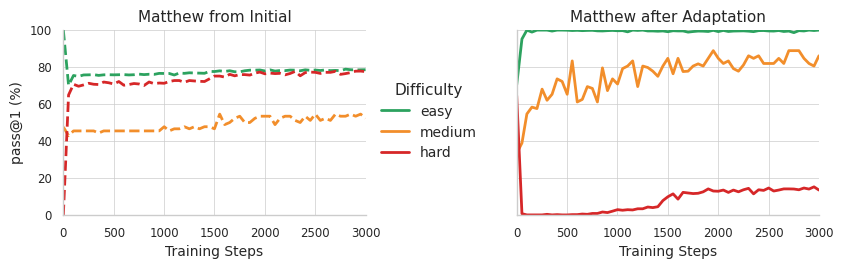

In [5]:
sns.set_theme(
    context="paper",
    style="whitegrid",
    palette="Blues",
    font="DejaVu Sans",
    rc={
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.labelsize": 10,
        "axes.titlesize": 11,
        "legend.fontsize": 8.5,
        "legend.title_fontsize": 9,
        "xtick.labelsize": 8.5,
        "ytick.labelsize": 8.5,
        "grid.linewidth": 0.5,
        "lines.linewidth": 2.0,
    },
)
mpl.rcParams["pdf.fonttype"] = 42
mpl.rcParams["ps.fonttype"] = 42

MAX_STEP = max(steps)

fig, axes = plt.subplots(1, 2, figsize=(9.75, 2.4), sharey=True, gridspec_kw={"wspace": 0.5})
for ax, df, dashed, title in [
    (axes[0], df_init, True, "Matthew from Initial"),
    (axes[1], df_adapted, False, "Matthew after Adaptation"),
]:
    plot_df = df.copy()
    plot_df["pass_at_1_percent"] = plot_df["pass_rate"] * 100
    present = [b for b in BUCKET_ORDER if (plot_df["bucket"] == b).any()]
    palette = {b: BUCKET_COLORS[b] for b in present}
    sns.lineplot(
        data=plot_df,
        x="Step",
        y="pass_at_1_percent",
        hue="bucket",
        hue_order=present,
        palette=palette,
        estimator="mean",
        errorbar=None,
        ax=ax,
        linestyle="--" if dashed else "-",
        legend=False,
    )
    ax.set_title(title)
    ax.set_xlabel("Training Steps")
    ax.set_xlim(0, MAX_STEP)
    ax.set_xticks(range(0, MAX_STEP + STEP_BIN, STEP_BIN))
    ax.set_ylim(0, 100)
    sns.despine(ax=ax)
axes[0].set_ylabel("pass@1 (%)")
axes[1].set_ylabel("")

handles = [Line2D([0], [0], color=BUCKET_COLORS[b], lw=2.0, label=b) for b in BUCKET_ORDER]
fig.legend(handles=handles, title="Difficulty", frameon=False, loc="center", bbox_to_anchor=(0.5, 0.5), fontsize=10, title_fontsize=11)

pdf_out = OUTPUT_DIR / "manufactoria_matthew_side_by_side.pdf"
fig.savefig(pdf_out, bbox_inches="tight")
print(f"saved {pdf_out}")

## GRPO baseline vs NGU pass-rate metrics

Plots `eval/objective/pass_rate` (Per-Test Pass-Rate) and `eval/objective/all_pass` (All-Tests Pass) over training steps. The GRPO baseline is split across two runs (the second is a `_continue` from the first) and NGU is also split across two runs where the second one resumes at step 1500 but logs from `_step=0`, so its steps are shifted by +1500.

In [6]:
METHOD_RUNS = {
    "GRPO": [
        {"id": "e7k1e8sd", "step_offset": 0},
        {"id": "ym0d6bhz", "step_offset": 0},
    ],
    "NGU": [
        {"id": "qfi7ho0h", "step_offset": 0},
        {"id": "sfysvxc2", "step_offset": 1500},
    ],
}
METHOD_ORDER = ["GRPO", "NGU"]
METHOD_COLORS = {"GRPO": "#737373", "NGU": "#1f6fb4"}

OBJECTIVE_METRICS = {
    "pass_rate": "Combined Tests",
    "hard": "Hard Tests",
    "all_pass": "All-Tests Pass",
}
OBJECTIVE_KEYS = {
    "pass_rate": "eval/objective/pass_rate",
    "hard": "eval/test_pass_at_1/difficulty_1",
    "all_pass": "eval/objective/all_pass",
}


def fetch_method_history(method_runs: list[dict]) -> pd.DataFrame:
    keys = ["_step", *OBJECTIVE_KEYS.values()]
    frames = []
    for cfg in method_runs:
        run = api.run(f"{PROJECT_PATH}/{cfg['id']}")
        rows = []
        for row in run.scan_history(keys=keys, page_size=500):
            rec = {"raw_step": int(row["_step"]) + cfg["step_offset"], "run_id": run.id}
            for name, key in OBJECTIVE_KEYS.items():
                rec[name] = row.get(key)
            rows.append(rec)
        frames.append(pd.DataFrame(rows))
    return pd.concat(frames, ignore_index=True)


method_dfs: dict[str, pd.DataFrame] = {}
for method, runs_cfg in METHOD_RUNS.items():
    df = fetch_method_history(runs_cfg)
    df["method"] = method
    method_dfs[method] = df
    print(f"{method}: {len(df)} rows from {df['run_id'].nunique()} runs")

obj_df = pd.concat(method_dfs.values(), ignore_index=True)
obj_df = obj_df.dropna(subset=list(OBJECTIVE_METRICS), how="all")
obj_df["Step"] = obj_df["raw_step"]
obj_df = obj_df.sort_values(["method", "Step"]).reset_index(drop=True)
display(obj_df.head())

GRPO: 62 rows from 2 runs


NGU: 63 rows from 2 runs


,raw_step,run_id,pass_rate,hard,all_pass,method,Step
0,52,e7k1e8sd,0.330225,0.005477,0.0,GRPO,52
1,101,e7k1e8sd,0.671538,0.006139,0.0,GRPO,101
2,151,e7k1e8sd,0.719946,0.003118,0.0,GRPO,151
3,201,e7k1e8sd,0.732500,0.006178,0.0,GRPO,201
4,252,e7k1e8sd,0.734534,0.004560,0.0,GRPO,252


saved /home/mnoukhov/open-instruct-merge/notebooks/figures/manufactoria_grpo_vs_ngu.pdf


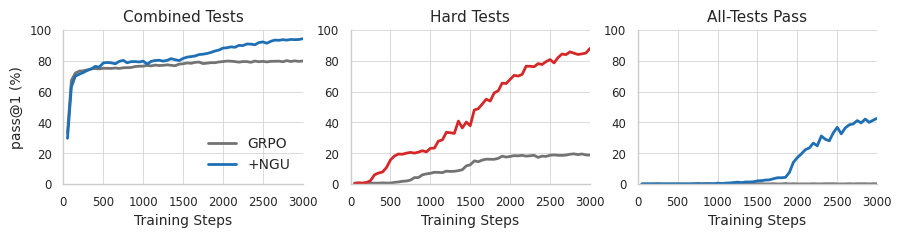

In [7]:
OBJ_MAX_STEP = int(obj_df["Step"].max())

fig, axes = plt.subplots(1, 3, figsize=(10.5, 2.0), sharex=True, gridspec_kw={"wspace": 0.2})
HARD_NGU_COLOR = "#d62728"
for ax, (metric_name, metric_title) in zip(axes, OBJECTIVE_METRICS.items()):
    sub = obj_df.dropna(subset=[metric_name])
    sub = sub.assign(value_pct=sub[metric_name] * 100)
    palette = dict(METHOD_COLORS)
    if metric_name == "hard":
        palette["NGU"] = HARD_NGU_COLOR
    sns.lineplot(
        data=sub,
        x="Step",
        y="value_pct",
        hue="method",
        hue_order=METHOD_ORDER,
        palette=palette,
        estimator="mean",
        errorbar=None,
        ax=ax,
        legend=False,
    )
    ax.set_title(metric_title)
    ax.set_xlabel("Training Steps")
    ax.set_ylabel("pass@1 (%)" if ax is axes[0] else "")
    ax.set_xlim(0, OBJ_MAX_STEP)
    ax.set_xticks(range(0, OBJ_MAX_STEP + STEP_BIN, STEP_BIN))
    ax.set_ylim(0, 100)
    sns.despine(ax=ax)

METHOD_LEGEND_LABELS = {"GRPO": "GRPO", "NGU": "+NGU"}
method_handles = [Line2D([0], [0], color=METHOD_COLORS[m], lw=2.0, label=METHOD_LEGEND_LABELS[m]) for m in METHOD_ORDER]
axes[0].legend(handles=method_handles, frameon=False, loc="lower right", fontsize=10)

obj_pdf = OUTPUT_DIR / "manufactoria_grpo_vs_ngu.pdf"
fig.savefig(obj_pdf, bbox_inches="tight")
print(f"saved {obj_pdf}")